In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
!pip install yfinance

  Using cached multitasking-0.0.12-py3-none-any.whl
  Using cached pytz-2025.2-py2.py3-none-any.whl.metadata (22 kB)
  Using cached frozendict-2.4.7-py3-none-any.whl.metadata (23 kB)
  Using cached peewee-3.19.0-py3-none-any.whl.metadata (7.0 kB)
  Using cached curl_cffi-0.13.0-cp39-abi3-macosx_11_0_arm64.whl.metadata (13 kB)
  Using cached protobuf-6.33.5-cp39-abi3-macosx_10_9_universal2.whl.metadata (593 bytes)
  Using cached websockets-16.0-cp313-cp313-macosx_11_0_arm64.whl.metadata (6.8 kB)
Using cached curl_cffi-0.13.0-cp39-abi3-macosx_11_0_arm64.whl (3.0 MB)
Using cached frozendict-2.4.7-py3-none-any.whl (16 kB)
Using cached peewee-3.19.0-py3-none-any.whl (411 kB)
Using cached protobuf-6.33.5-cp39-abi3-macosx_10_9_universal2.whl (427 kB)
Using cached pytz-2025.2-py2.py3-none-any.whl (509 kB)
Using cached websockets-16.0-cp313-cp313-macosx_11_0_arm64.whl (175 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8/8 [yfinance]7/8 [yfinance]s]


In [4]:
import yfinance as yf

ticker = "^GDAXI"  # DAX index
df = yf.download(ticker, start="2014-01-01", progress=False)

df.head()

Price,Close,High,Low,Open,Volume
Ticker,^GDAXI,^GDAXI,^GDAXI,^GDAXI,^GDAXI
Date,,,,,
2014-01-02,9400.040039,9620.929688,9394.209961,9598.250000,90956900
2014-01-03,9435.150391,9453.480469,9367.990234,9409.660156,58772900
2014-01-06,9428.000000,9468.799805,9399.809570,9419.440430,53653700
2014-01-07,9506.200195,9518.719727,9416.860352,9446.250000,79946800
2014-01-08,9497.839844,9516.259766,9467.950195,9512.790039,90140400


In [5]:
df.to_csv("../data/raw/dax_raw.csv")
print("Saved raw data.")

Saved raw data.


In [6]:
close = df["Close"].dropna()

ret = 100 * np.log(close / close.shift(1))
ret = ret.dropna()

ret.name = "log_return"
ret.head()

Ticker,^GDAXI
Date,
2014-01-03,0.372817
2014-01-06,-0.075813
2014-01-07,0.826025
2014-01-08,-0.087985
2014-01-09,-0.805836


In [7]:
ret.to_csv("../data/processed/dax_log_returns.csv")
print("Saved processed returns.")

Saved processed returns.


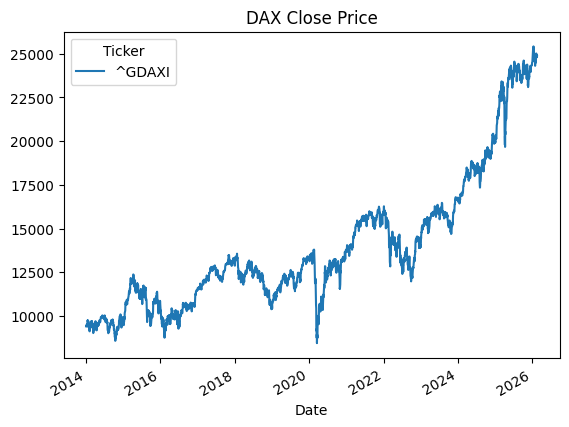

In [8]:
close.plot(title="DAX Close Price")
plt.show()

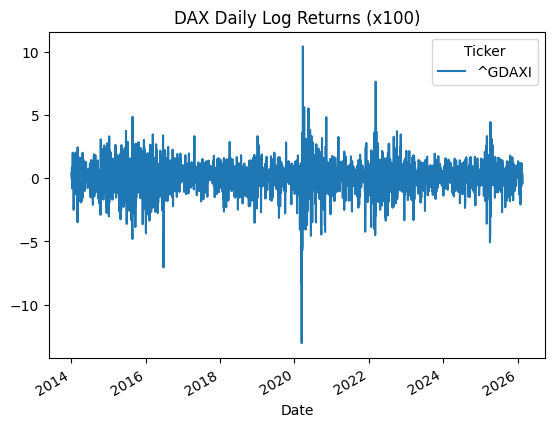

In [9]:
ret.plot(title="DAX Daily Log Returns (x100)")
plt.show()

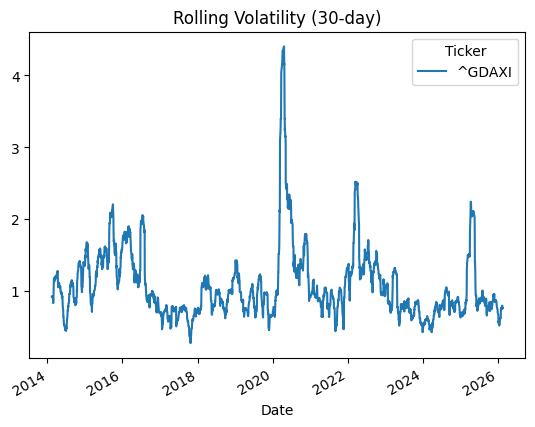

In [10]:
rolling_vol = ret.rolling(30).std()

rolling_vol.plot(title="Rolling Volatility (30-day)")
plt.show()

In [11]:
from scipy import stats

desc = pd.Series({
    "mean": ret.mean(),
    "std": ret.std(),
    "min": ret.min(),
    "max": ret.max(),
    "skewness": stats.skew(ret),
    "kurtosis": stats.kurtosis(ret, fisher=False)  # Pearson kurtosis
})

desc

mean         Ticker
^GDAXI    0.031658
dtype: float64
std          Ticker
^GDAXI    1.188339
dtype: float64
min         Ticker
^GDAXI   -13.054859
dtype: float64
max         Ticker
^GDAXI    10.414287
dtype: float64
skewness                        [-0.5796967872811293]
kurtosis                         [12.885490709897098]
dtype: object

In [12]:
jb_stat, jb_pvalue = stats.jarque_bera(ret)

print(f"Jarque-Bera stat: {jb_stat:.3f}")
print(f"p-value: {jb_pvalue:.6f}")

Jarque-Bera stat: 12688.847
p-value: 0.000000


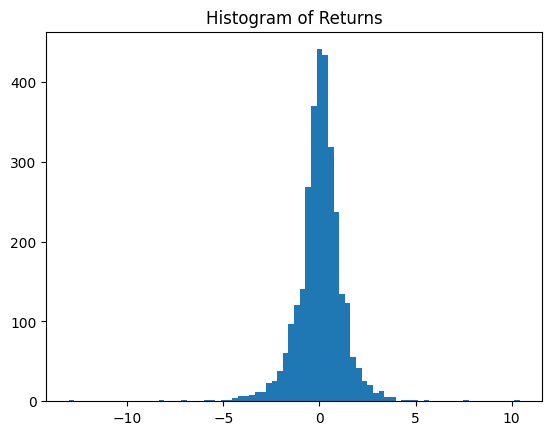

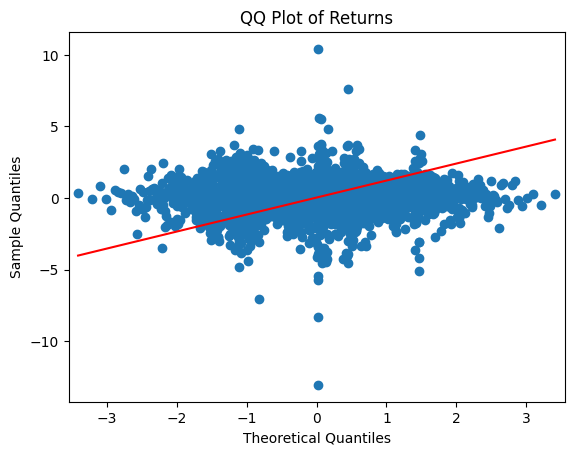

In [14]:
plt.figure()
plt.hist(ret, bins=80)
plt.title("Histogram of Returns")
plt.show()
import statsmodels.api as sm

sm.qqplot(ret, line="s")
plt.title("QQ Plot of Returns")
plt.show()

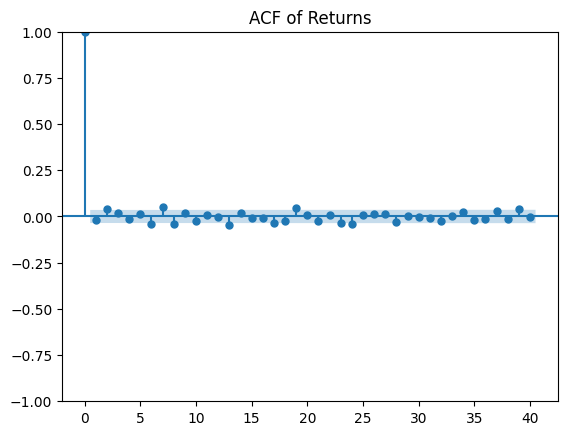

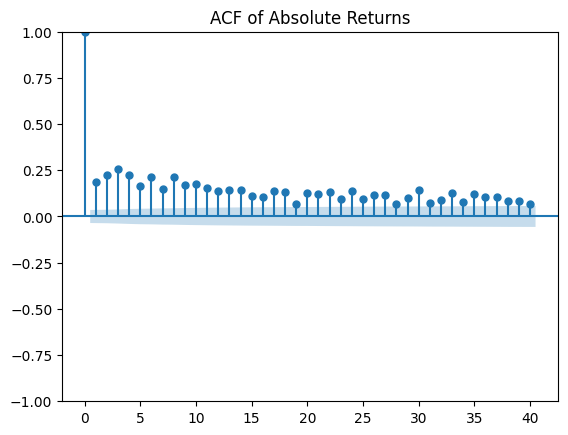

In [15]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(ret, lags=40)
plt.title("ACF of Returns")
plt.show()

plot_acf(np.abs(ret), lags=40)
plt.title("ACF of Absolute Returns")
plt.show()

In [16]:
from statsmodels.stats.diagnostic import het_arch

arch_stat, arch_pvalue, _, _ = het_arch(ret)

print(f"ARCH LM stat: {arch_stat:.3f}")
print(f"p-value: {arch_pvalue:.6f}")

ARCH LM stat: 577.106
p-value: 0.000000


In [18]:
desc.to_csv("../results/tables/stylized_facts_summary.csv")
print("Saved: results/tables/stylized_facts_summary.csv")

Saved: results/tables/stylized_facts_summary.csv
